In [1]:
import torch
from transformers import LayoutLMv3Processor, LayoutLMv3ForTokenClassification
from datasets import load_dataset
from PIL import Image
from io import BytesIO
import re
import requests

/opt/homebrew/Caskroom/miniforge/base/envs/ml-cli/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load the processor and model
processor = LayoutLMv3Processor.from_pretrained("nielsr/layoutlmv3-finetuned-cord")
model = LayoutLMv3ForTokenClassification.from_pretrained("nielsr/layoutlmv3-finetuned-cord")


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'RobertaTokenizer'. 
The class this function is called from is 'LayoutLMv3TokenizerFast'.


In [3]:
# Set the device
device = "cuda" if torch.cuda.is_available() else "mps"
model.to(device)

LayoutLMv3ForTokenClassification(
  (layoutlmv3): LayoutLMv3Model(
    (embeddings): LayoutLMv3TextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (x_position_embeddings): Embedding(1024, 128)
      (y_position_embeddings): Embedding(1024, 128)
      (h_position_embeddings): Embedding(1024, 128)
      (w_position_embeddings): Embedding(1024, 128)
    )
    (patch_embed): LayoutLMv3PatchEmbeddings(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
    (encoder): LayoutLMv3Encoder

In [4]:
# Get Open Food Facts dataset
image_prefix_url = "https://prices.openfoodfacts.org/img/"
dataset = load_dataset("hf-internal-testing/example-documents", split="test")
dataset_ofp = load_dataset("openfoodfacts/open-prices")['prices']
dataset_ofp = dataset_ofp.filter(lambda x: x['proof_type'] == 'RECEIPT')
image_url = image_prefix_url+dataset_ofp[0]['proof_file_path']
response = requests.get(image_url)
response.raise_for_status()
image = Image.open(BytesIO(response.content))
# image = dataset[2]["image"]
image.show()

Generating prices split: 57740 examples [00:00, 391330.38 examples/s]
Filter: 100%|██████████| 57740/57740 [00:02<00:00, 22907.66 examples/s]


In [5]:
# Preprocess the image
encoding = processor(image, return_tensors="pt")
input_ids = encoding["input_ids"].to(device)
attention_mask = encoding["attention_mask"].to(device)
bbox = encoding["bbox"].to(device)
pixel_values = encoding["pixel_values"].to(device)


In [6]:
# Perform inference
with torch.no_grad():
    outputs = model(input_ids=input_ids, attention_mask=attention_mask, bbox=bbox, pixel_values=pixel_values)
    logits = outputs.logits

# Get the predicted class labels
predicted_class_indices = logits.argmax(-1).squeeze().tolist()
labels = processor.tokenizer.convert_ids_to_tokens(predicted_class_indices)

# Print the results
print(labels)

/opt/homebrew/Caskroom/miniforge/base/envs/ml-cli/lib/python3.12/site-packages/transformers/modeling_utils.py:1161: FutureWarning: The `device` argument is deprecated and will be removed in v5 of Transformers.
  warnings.warn(


['Ġfrom', 'Ġat', 'Ġyou', 'Ġwe', 'Ġwe', '<pad>', 'Ġfrom', 'Ġfrom', 'Ġfrom', 'Ġfrom', '<pad>', 'Ġhas', 'Ġhas', 'Ġhas', 'Ġhas', '.', '.', '<unk>', '<unk>', '<unk>', 'Ġ(', ',', ',', ',', 'Ġa', 'Ġwill', 'Ġa', 'Ġwill', 'Ġwill', 'Ġwill', ',', '</s>', 'Ġhas', 'Ġa', 'Ġhas', '.', 'Ġhas', 'Ġhas', 'Ġa', 'Ġhas', 'Ġhas', ',', ',', 'Ġ(', '.', '.', '<pad>', 'Ġhas', 'Ġhas', '<unk>', '.', '<unk>', '<unk>', '<unk>', 'Ġ(', 'Ġ(', '.', '<pad>', 'Ġfrom', '.', '<unk>', '<unk>', ',', ',', ',', ',', '.', '<pad>', 'Ġfrom', 'Ġfrom', 'Ġfrom', 'Ġfrom', 'Ġfrom', '.', '<unk>', '<unk>', '<pad>', 'Ġfrom', 'Ġfrom', 'Ġfrom', 'Ġfrom', '<pad>', 'Ġfrom', 'Ġfrom', 'Ġfrom', ',', ',', ',', '<pad>', 'Ġfrom', 'Ġfrom', '<pad>', 'Ġfrom', 'Ġfrom', '<pad>', 'Ġfrom', 'Ġwill', 'Ġwill', 'Ġwill', 'Ġwas', 'Ġwas', 'Ġwas', 'Ġthey', 'Ġthey', 'Ġthey', 'Ġwas', 'Ġwas', 'Ġthey', '.', '.', ',', 'Ġfor', ',', 'Ġfor', 'Ġfor', 'Ġfor', 'Ġwas', 'Ġthey', 'Ġthey', 'Ġwas', 'Ġthey', 'Ġat', ',', '<unk>', 'Ġthey', 'Ġthey', '<unk>', '<unk>', '<unk>', '<unk>'

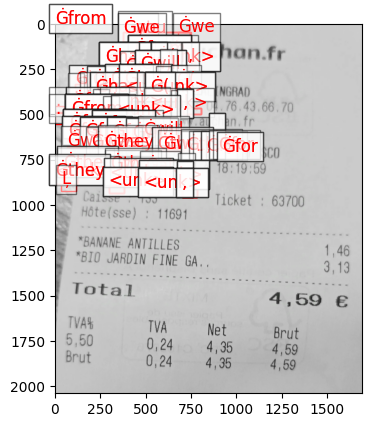

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Display the image
fig, ax = plt.subplots(1)
ax.imshow(image)

# Get the bounding boxes and labels
bboxes = encoding["bbox"].squeeze().tolist()
labels = processor.tokenizer.convert_ids_to_tokens(predicted_class_indices)

# Plot the bounding boxes and labels
for bbox, label in zip(bboxes, labels):
    if label != "[PAD]":
        x, y, w, h = bbox[0], bbox[1], bbox[2] - bbox[0], bbox[3] - bbox[1]
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        plt.text(x, y, label, color='red', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

plt.show()